# Anomaly Detection Dataset Generation

`make_anomaly_dataset` generates a collection of **multivariate time-series instances**. Every instance shares a smooth baseline (a superposition of the signal primitives used by the classification module) plus Gaussian measurement noise. A configurable fraction of the instances are *anomalous*: they carry one or more **positive triangular spikes** whose amplitude, width, count, and location are drawn at random within user-controlled ranges.

The generator returns an `AnomalyDataset` dataclass with:
- `y` — the main data tensor, shape `(N, m, T)`: `N` instances, `m` channels, length `T`
- `labels` — per-instance class, shape `(N,)`: `0` = normal, `1` = anomaly
- `t` — the shared time grid, shape `(T,)`
- `peak_indices` — a list of `LongTensor`s, the ground-truth spike centres of each instance (empty for normal instances)

This notebook demonstrates:
- The default single-channel dataset and its ground-truth spikes
- Tuning the spikes through the `SpikeParams` dataclass
- A custom baseline via `channel_params`
- Multivariate instances where spikes share their timing across channels
- Optional train / validation / test splitting
- PyTorch `DataLoader` integration
- Evaluating a detector with `ClassifierMetrics`

In [1]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from artificial_dataset import (
    ClassifierMetrics,
    SpikeParams,
    make_anomaly_dataset,
)

## Default dataset

The default baseline is `0.6 * sin(t)` over `[0, 6π]`. Normal instances are just that baseline plus noise; anomalous instances add a handful of positive spikes. The spike centres recorded in `peak_indices` are the ground truth we would ask a detector to recover.

y shape      : (200, 1, 1000)
labels shape : (200,)
anomalies    : 10 / 200


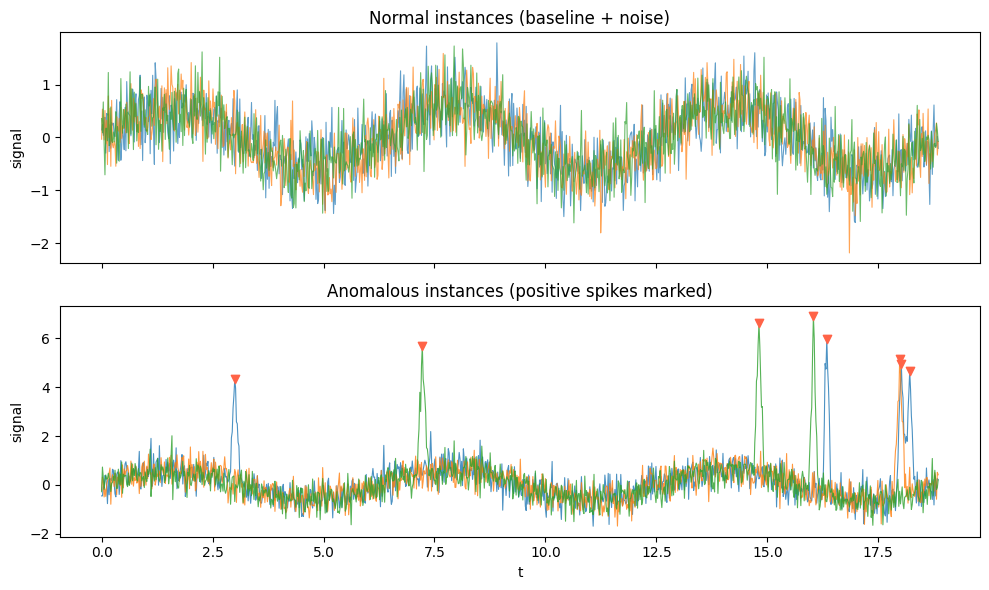

In [2]:
data = make_anomaly_dataset(
    n_instances=200,
    series_length=1000,
    anomaly_fraction=0.05,
    random_state=0,
)

print(f"y shape      : {tuple(data.y.shape)}")  # (N, m, T)
print(f"labels shape : {tuple(data.labels.shape)}")
print(f"anomalies    : {int(data.labels.sum())} / {len(data.labels)}")

normal_idx = (data.labels == 0).nonzero(as_tuple=True)[0]
anomaly_idx = (data.labels == 1).nonzero(as_tuple=True)[0]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i in normal_idx[:3].tolist():
    axes[0].plot(data.t, data.y[i, 0], lw=0.8, alpha=0.7)
axes[0].set_title("Normal instances (baseline + noise)")
axes[0].set_ylabel("signal")

for i in anomaly_idx[:3].tolist():
    axes[1].plot(data.t, data.y[i, 0], lw=0.8, alpha=0.8)
    peaks = data.peak_indices[i]
    axes[1].scatter(
        data.t[peaks],
        data.y[i, 0][peaks],
        color="tomato",
        marker="v",
        zorder=5,
        label="spike centre",
    )
axes[1].set_title("Anomalous instances (positive spikes marked)")
axes[1].set_xlabel("t")
axes[1].set_ylabel("signal")
plt.tight_layout()
plt.show()

## Tuning the spikes with `SpikeParams`

Every spike property is random but configurable through the `SpikeParams` dataclass: `amplitude_range` (sampled per channel), `width_range` (the triangular half-width), `count_range` (spikes per anomalous instance), and `margin` (keeps spikes off the edges). Each value is drawn uniformly from its inclusive range.

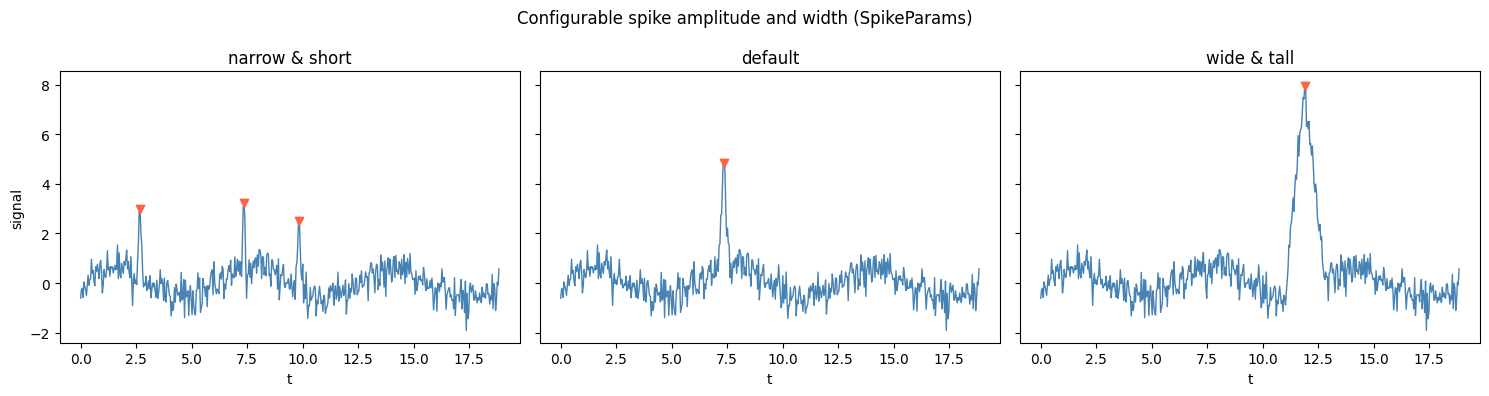

In [3]:
configs = {
    "narrow & short": SpikeParams(
        amplitude_range=(2.0, 3.0), width_range=(2, 4), count_range=(2, 4)
    ),
    "default": SpikeParams(),
    "wide & tall": SpikeParams(
        amplitude_range=(8.0, 10.0), width_range=(15, 25), margin=40
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, spikes) in zip(axes, configs.items(), strict=True):
    d = make_anomaly_dataset(
        n_instances=20,
        series_length=500,
        anomaly_fraction=0.5,
        spike_params=spikes,
        random_state=1,
    )
    a = (d.labels == 1).nonzero(as_tuple=True)[0][0].item()
    peaks = d.peak_indices[a]
    ax.plot(d.t, d.y[a, 0], lw=1.0, color="steelblue")
    ax.scatter(d.t[peaks], d.y[a, 0][peaks], color="tomato", marker="v", zorder=5)
    ax.set_title(name)
    ax.set_xlabel("t")
axes[0].set_ylabel("signal")
plt.suptitle("Configurable spike amplitude and width (SpikeParams)")
plt.tight_layout()
plt.show()

## Custom baseline

`channel_params` is a list of signal-parameter dicts — one per channel. Any combination of `"linear"`, `"polynomial"`, and `"sinusoidal"` keys defines the normal-behaviour pattern that the spikes are added on top of.

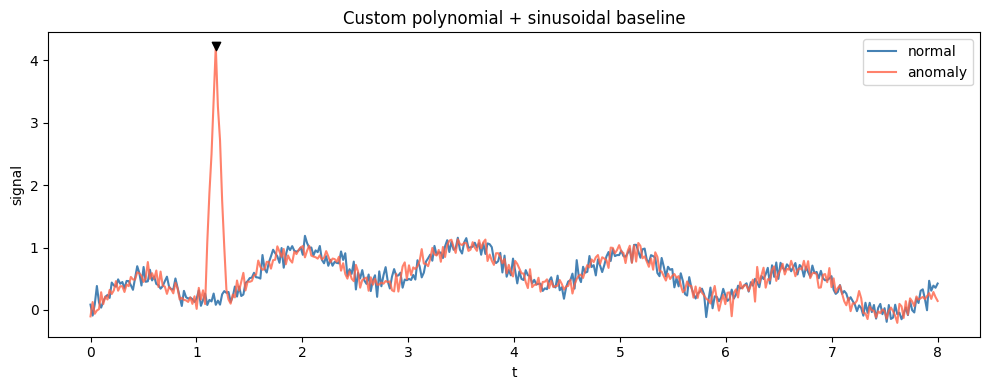

In [4]:
channel_params = [
    {
        "polynomial": {"coefficients": [0.0, 0.5, -0.1, 0.005]},
        "sinusoidal": {"amplitude": 0.3, "frequency": 4.0, "phase": 0.0},
    }
]

data_custom = make_anomaly_dataset(
    n_instances=60,
    series_length=400,
    anomaly_fraction=0.1,
    noise_std=0.1,
    x_range=(0.0, 8.0),
    channel_params=channel_params,
    random_state=2,
)

normal_i = (data_custom.labels == 0).nonzero(as_tuple=True)[0][0].item()
anomaly_i = (data_custom.labels == 1).nonzero(as_tuple=True)[0][0].item()
peaks = data_custom.peak_indices[anomaly_i]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    data_custom.t,
    data_custom.y[normal_i, 0],
    color="steelblue",
    label="normal",
)
ax.plot(
    data_custom.t,
    data_custom.y[anomaly_i, 0],
    color="tomato",
    alpha=0.8,
    label="anomaly",
)
ax.scatter(
    data_custom.t[peaks],
    data_custom.y[anomaly_i, 0][peaks],
    color="black",
    marker="v",
    zorder=5,
)
ax.set_xlabel("t")
ax.set_ylabel("signal")
ax.set_title("Custom polynomial + sinusoidal baseline")
ax.legend()
plt.tight_layout()
plt.show()

## Multivariate instances

Pass more than one entry to `channel_params` to get `m > 1` channels. Within an anomalous instance the spike *events* share their centre and width across all channels — one event hits every channel at the same time — while each channel responds with its own random amplitude. The shared `peak_indices` therefore line up across channels.

y shape : (50, 2, 600)


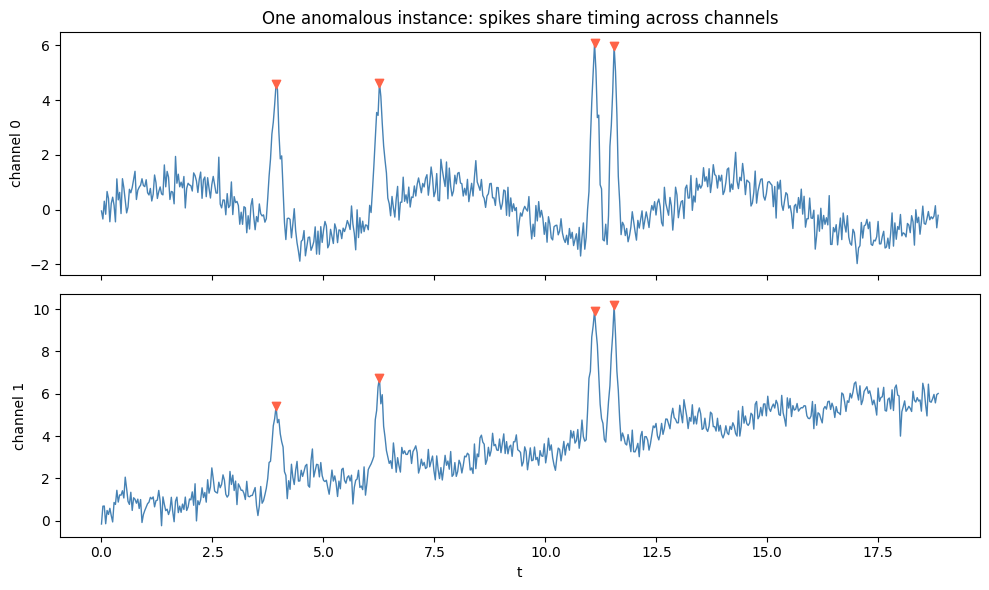

In [5]:
channel_params_mc = [
    {"sinusoidal": {"amplitude": 1.0, "frequency": 1.0, "phase": 0.0}},
    {
        "linear": {"slope": 0.3, "intercept": 0.5},
        "sinusoidal": {"amplitude": 0.4, "frequency": 3.0, "phase": 0.0},
    },
]

data_mc = make_anomaly_dataset(
    n_instances=50,
    series_length=600,
    anomaly_fraction=0.2,
    channel_params=channel_params_mc,
    random_state=4,
)
print(f"y shape : {tuple(data_mc.y.shape)}")  # (N, 2, T)

a = (data_mc.labels == 1).nonzero(as_tuple=True)[0][0].item()
peaks = data_mc.peak_indices[a]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(data_mc.t, data_mc.y[a, ch], lw=1.0, color="steelblue")
    ax.scatter(
        data_mc.t[peaks],
        data_mc.y[a, ch][peaks],
        color="tomato",
        marker="v",
        zorder=5,
    )
    ax.set_ylabel(f"channel {ch}")
axes[0].set_title("One anomalous instance: spikes share timing across channels")
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

## Train / validation / test splitting

Pass `split=(train, val, test)` to receive an `AnomalySplits` instead of a single dataset. Instances are cut **contiguously from the beginning**, but because anomalies are scattered randomly through the collection, each subset keeps roughly the requested anomaly rate. The same partition is available as `dataset.split((...))` on an existing `AnomalyDataset`.

In [6]:
splits = make_anomaly_dataset(
    n_instances=400,
    series_length=256,
    anomaly_fraction=0.1,
    split=(0.7, 0.15, 0.15),
    random_state=6,
)

for name, subset in [
    ("train", splits.train),
    ("val", splits.val),
    ("test", splits.test),
]:
    n = subset.y.shape[0]
    n_anom = int(subset.labels.sum())
    print(f"{name:5s}: {n:3d} instances, {n_anom:2d} anomalies ({n_anom / n:.1%})")

train: 280 instances, 28 anomalies (10.0%)
val  :  60 instances,  7 anomalies (11.7%)
test :  60 instances,  5 anomalies (8.3%)


## PyTorch `DataLoader` integration

The `(N, m, T)` tensor and the `(N,)` labels drop straight into a `TensorDataset`, so each batch is a stack of multivariate series ready for a 1-D convolutional or recurrent model.

In [7]:
data_dl = make_anomaly_dataset(
    n_instances=500,
    series_length=128,
    anomaly_fraction=0.05,
    random_state=3,
)

dataset = TensorDataset(data_dl.y, data_dl.labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

batch_y, batch_labels = next(iter(loader))
print(f"Dataset size       : {len(dataset)}")
print(f"Batches per epoch  : {len(loader)}")
print(f"Batch y shape      : {tuple(batch_y.shape)}")  # (32, m, T)
print(f"Batch labels shape : {tuple(batch_labels.shape)}")

Dataset size       : 500
Batches per epoch  : 16
Batch y shape      : (32, 1, 128)
Batch labels shape : (32,)


## Evaluating a detector with `ClassifierMetrics`

Because the spikes are always positive and much taller than the baseline envelope, a simple per-instance rule — flag an instance whose largest value crosses a threshold — already recovers most anomalies. `ClassifierMetrics.from_anomaly_indices` then compares the detected instance positions against the ground-truth ones.

In [8]:
data_ev = make_anomaly_dataset(
    n_instances=400,
    series_length=512,
    anomaly_fraction=0.1,
    random_state=10,
)

# Detector: an instance is anomalous if any channel rises above a
# threshold sitting well past the noisy baseline envelope.
instance_max = data_ev.y.amax(dim=(1, 2))
pred_indices = (instance_max > 2.0).nonzero(as_tuple=True)[0]
true_indices = (data_ev.labels == 1).nonzero(as_tuple=True)[0]

metrics = ClassifierMetrics.from_anomaly_indices(
    n_samples=data_ev.y.shape[0],
    true_indices=true_indices,
    pred_indices=pred_indices,
)

print(f"Accuracy  : {metrics.accuracy:.3f}")
print(f"Precision : {metrics.precision:.3f}")
print(f"Recall    : {metrics.recall:.3f}")
print(f"F1 score  : {metrics.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(metrics.confusion_matrix)

Accuracy  : 0.985
Precision : 0.935
Recall    : 0.992
F1 score  : 0.961

Confusion matrix (rows = true, cols = predicted):
tensor([[354,   6],
        [  0,  40]])
